### Import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_log_error

### Load data

In [3]:
# Load data
train_data = pd.read_csv('/Users/robertocarlos/Documents/datasets/nyc-taxi-trip-duration/train.csv')
test_data = pd.read_csv('/Users/robertocarlos/Documents/datasets/nyc-taxi-trip-duration/test.csv')

### Preprocessing

In [4]:
# Train data exploration
print(train_data.shape)
train_data.head()

(1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
# Train data information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
# Test data exploration
print(test_data.shape)
test_data.head()

(625134, 9)


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [7]:
# Test data information
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  625134 non-null  object 
 1   vendor_id           625134 non-null  int64  
 2   pickup_datetime     625134 non-null  object 
 3   passenger_count     625134 non-null  int64  
 4   pickup_longitude    625134 non-null  float64
 5   pickup_latitude     625134 non-null  float64
 6   dropoff_longitude   625134 non-null  float64
 7   dropoff_latitude    625134 non-null  float64
 8   store_and_fwd_flag  625134 non-null  object 
dtypes: float64(4), int64(2), object(3)
memory usage: 42.9+ MB


### Feature engineering

In [8]:
# Convert pickup datetime columns to datetime objects
train_data['pickup_datetime'] = pd.to_datetime(train_data['pickup_datetime'])
test_data['pickup_datetime'] = pd.to_datetime(test_data['pickup_datetime'])


# Extract datetime features
for df in [train_data, test_data]:
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_day"] = df["pickup_datetime"].dt.dayofweek
    df["pickup_month"] = df["pickup_datetime"].dt.month

# Create weekend and rush hour features
for df in [train_data, test_data]:
    df['is_weekend'] = df['pickup_day'].isin([5,6]).astype(int)
    df['rush_hour'] = df['pickup_hour'].isin([8,9,10,16,17,18,19]).astype(int)

In [9]:
# Haversine distance function to calculate the great-circle distance between two points on the Earth
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lambda / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

for df in [train_data, test_data]:
    df["haversine_distance"] = haversine_distance(df["pickup_latitude"], df["pickup_longitude"],
                                                 df["dropoff_latitude"], df["dropoff_longitude"])

In [10]:
# Manhattan distance function to calculate the distance between two points in a grid-based path (like navigating through city blocks)
def manhattan_distance(lat1, lon1, lat2, lon2):
    return np.abs(lat2 - lat1) + np.abs(lon2 - lon1)

for df in [train_data, test_data]:
    df["manhattan_distance"] = manhattan_distance(df["pickup_latitude"], df["pickup_longitude"],
                                                 df["dropoff_latitude"], df["dropoff_longitude"])

In [11]:
# Target variable exploration (outliers)
train_data["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

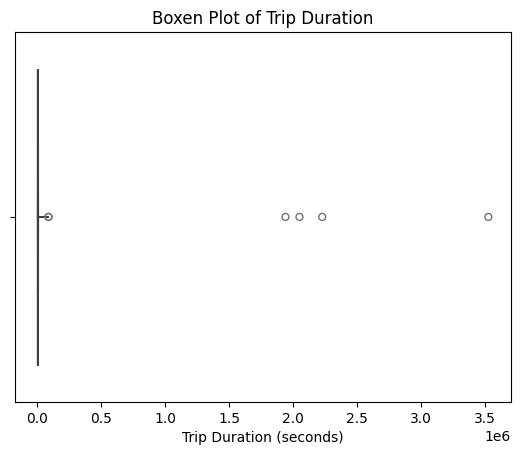

In [12]:
# Boxen plot of the target variable
sns.boxenplot(x=train_data["trip_duration"])
plt.title("Boxen Plot of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.show()

Dataset is extremely "bottom-heavy." With a median (50th percentile) of 662 but a maximum of 3,526,282.

The Floor: A taxi ride of 1 (unit) is likely a technical error or an immediate cancellation.

The Ceiling: A value of 3.5 million (40 days) is almost certainly a meter left running or a GPS glitch.

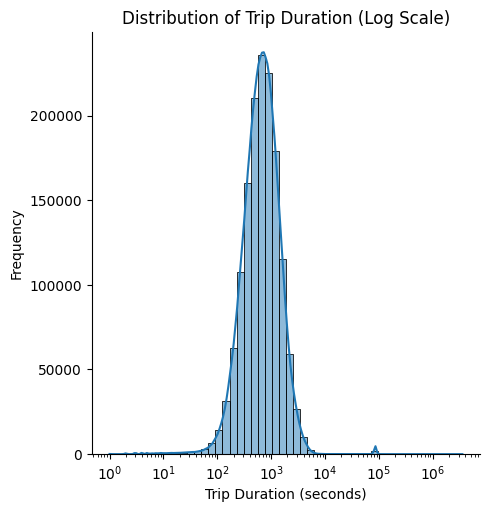

In [13]:
#Log-scale histogram of the target variable

sns.displot(train_data["trip_duration"], kind="hist", bins=50, log_scale=True, kde=True)
plt.title("Distribution of Trip Duration (Log Scale)")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


In [14]:
# Remove extreme outliers (bottom and upper 1%)
# Calculate the thresholds
lower_limit = train_data['trip_duration'].quantile(0.01)
upper_limit = train_data['trip_duration'].quantile(0.99)

# Keep only the data within those limits
train_data = train_data[(train_data['trip_duration'] >= lower_limit) & 
                        (train_data['trip_duration'] <= upper_limit)]

### Feature Sets

In [15]:
# Prepare the data for modeling
BASE_FEATURES = ["passenger_count", "pickup_hour", "pickup_day", "pickup_month", "is_weekend", "rush_hour"]

HAVERSINE_DISTANCE = BASE_FEATURES + ["haversine_distance"]
MANHATTAN_DISTANCE = BASE_FEATURES + ["manhattan_distance"]

### Models

In [16]:
def get_random_forest_model():
    return RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

def get_xgboost_model():
    return XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)

def get_gbr_model():
    return GradientBoostingRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)

### Train validation split

In [17]:
# Train models
def run_experiment(model, features, train_data):

    X = train_data[features]
    y = train_data["trip_duration"]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = root_mean_squared_log_error(y_val, y_pred)
    print(f"Model: {model.__class__.__name__}, Features: {features}, RMSLE: {score:.4f}")

    return score

### Track results

In [18]:
# Run experiments with different models and feature sets
results = []

experiments = [
    ("RF_base", get_random_forest_model(), BASE_FEATURES),
    ("RF_haversine", get_random_forest_model(), HAVERSINE_DISTANCE),
    ("RF_manhattan", get_random_forest_model(), MANHATTAN_DISTANCE),
    ("XGB_base", get_xgboost_model(), BASE_FEATURES),
    ("XGB_haversine", get_xgboost_model(), HAVERSINE_DISTANCE),
    ("XGB_manhattan", get_xgboost_model(), MANHATTAN_DISTANCE),
    ("GBR_base", get_gbr_model(), BASE_FEATURES),
    ("GBR_haversine", get_gbr_model(), HAVERSINE_DISTANCE),
    ("GBR_manhattan", get_gbr_model(), MANHATTAN_DISTANCE)
]

for name, model, features in experiments:
    score = run_experiment(model, features, train_data)

    results.append({
        "model": name,
        "features": features,
        "score": score
    })

    print(f"Experiment: {name}, RMSLE: {score:.4f}")

Model: RandomForestRegressor, Features: ['passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'rush_hour'], RMSLE: 0.7264
Experiment: RF_base, RMSLE: 0.7264
Model: RandomForestRegressor, Features: ['passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'rush_hour', 'haversine_distance'], RMSLE: 0.3982
Experiment: RF_haversine, RMSLE: 0.3982
Model: RandomForestRegressor, Features: ['passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'rush_hour', 'manhattan_distance'], RMSLE: 0.4112
Experiment: RF_manhattan, RMSLE: 0.4112
Model: XGBRegressor, Features: ['passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'rush_hour'], RMSLE: 0.7267
Experiment: XGB_base, RMSLE: 0.7267
Model: XGBRegressor, Features: ['passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'is_weekend', 'rush_hour', 'haversine_distance'], RMSLE: 0.3960
Experiment: XGB_haversine, RMSLE: 0.3960
Model: XGBRegressor, Feat

### Compare results

In [19]:
results_df = pd.DataFrame(results).sort_values("score")
results_df

,model,features,score
7,GBR_haversine,"[passenger_count, pickup_hour, pickup_day, pic...",0.395203
4,XGB_haversine,"[passenger_count, pickup_hour, pickup_day, pic...",0.395955
1,RF_haversine,"[passenger_count, pickup_hour, pickup_day, pic...",0.398183
8,GBR_manhattan,"[passenger_count, pickup_hour, pickup_day, pic...",0.408328
5,XGB_manhattan,"[passenger_count, pickup_hour, pickup_day, pic...",0.409022
2,RF_manhattan,"[passenger_count, pickup_hour, pickup_day, pic...",0.411217
0,RF_base,"[passenger_count, pickup_hour, pickup_day, pic...",0.726397
3,XGB_base,"[passenger_count, pickup_hour, pickup_day, pic...",0.726742
6,GBR_base,"[passenger_count, pickup_hour, pickup_day, pic...",0.726819


In [20]:
# Predict on test set
X_test = test_data[HAVERSINE_DISTANCE]

Y_pred_test = model.predict(X_test)

test_data["trip_duration"] = Y_pred_test

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- haversine_distance
Feature names seen at fit time, yet now missing:
- manhattan_distance
